## Applied Math 10: Computing for Science and Engineering

### Lab 7 : Numerical Integration of functions

**Fall 2020**<br/>
<br>


### Learning Goals

This Lab focuses on numerically calculating integrals by means of the rectangular approximation, the trapezoidal approximation, and the Simpson's 1/3 rule. By the end of this lab, you will be familiar with:
- writing functions for calculating integrals
- using them to compute integrals

___________________________________________________________________________________________________________________________

In [1]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt
import scipy.integrate as spi
import time

Reference on numpy functions¶
https://docs.scipy.org/doc/numpy-1.13.0/reference/routines.math.html

### Functions for rectangular, trapezoidal, and Simpson approximations

In Lecture 7, three methods for approximating a definite integral were explored. It is convenient to cast these methods as functions that can be used for calculating any integral. We will start by writing a function for the rectangular approximation. Recall the expression for the integral using the rectangular method is:

$$ I(a,b) \approx \sum_{n=0}^N f(x_n) \Delta x + {\cal O}[(\Delta x)^2]$$

The following is a function implements the above approximation for any function $f$ that has been discretized between the limits $xmin$ and $xmax$. The second term in the above expression shows the error in this approximation and you will not include that in the code.

In [2]:
def rectnv(f, xmin, xmax):
    
    '''  The input is: discretized values of the function, f;
                   lower and upper limits of integration, xmin and xmax
         The output is: the integral of the function f between the lower and upper limits xmin and xmax
    '''
    #Find Nx from the discretized function f

    Nx=len(f)-1
    
    #Find Dx 
    
    Dx = (xmax - xmin) / Nx
    
    #Write the expression for integral
    
    Ints = Dx * np.sum(f)-Dx*f[Nx]
    
    return Ints

#### Example: 

Use `rectnv` to calculate the integral $\int_{-\pi / 4}^{+\pi /4} f(x) dx$, where $f(x) = \frac{\cos (4 \pi x)}{\sqrt{1-x}}$

In [3]:
# This is the same function that was used as an example in Lecture 7.

def fofx(x):
# check to make sure function does not blow up
    if x==1.0:
        return 0.0
    else:
        return np.cos(4.0*np.pi*x)/np.sqrt(1.0-x)


In [4]:
# From theory, we know that the exact value of this integral is:

Iexact = -0.115881

In [5]:
#Define the lower and upper limits of integration and discretize the function

xmin=-np.pi/4.0
xmax=np.pi/4.0
Nx=64
x=np.linspace(xmin,xmax,Nx+1)
f=np.zeros(Nx+1)
for n in range(Nx+1):
    f[n]=fofx(x[n])

In [6]:
#Call the function rectnv to compute the approximate value of the integral.
I_rect=rectnv(f, xmin, xmax)
print(I_rect)

-0.0996875541190456


In [7]:
# Compare the approximate value with the exact value of the integral

Difs = I_rect - Iexact

print(Difs)

0.016193445880954394


___________________________________________________________________________________________________________________________

### The trapezoidal method

From Lecture 7, recall the trapezoidal approximation for the integral is:

$$ I(a,b) \approx \frac{1}{2} \left [ f(x_0) + 2 \sum_{n=1}^{N-1} f(x_n) + f(x_{N}) \right ] \Delta x + {\cal O}[(\Delta x)^3]$$

As the second term indicates, this method is more accurate than the rectangular method.

**Exercise: Write a function for the trapezoidal method**

Inputs to the function:
- Discretized function
- The lower and upper limits (xmin and xmax)

Expected output:
- The value of the integral

In [8]:
def trapznv(f, xmin, xmax):
    
    ''' The input is: discretized values of the function, f;
                   lower and upper limits of integration, xmin and xmax
        The output is: the integral of the function f between the lower and upper limits xmin and xmax
    '''
    
    # Find Nx (number of intervals)
    
    Nx=len(f)-1
    
    #Find Dx
    
    Dx = (xmax - xmin) / Nx
    
    #Find the integral
    
    Ints=Dx*np.sum(f)-0.5*Dx*f[0]-0.5*Dx*f[Nx]
    
    return Ints

___________________________________________________________________________________________________________________________

### The Simpson's method

Again, from Lecture 7, recall resulting expression for the Simpson's approximation is:

$$ I(a,b) \approx \frac{1}{3} \left [ f(x_0) + 4 \sum_{n=1}^{N/2} f(x_{2n-1}) 
+ 2 \sum_{n=1}^{N/2-1} f(x_{2n}) + f(x_{N}) \right ] \Delta x + {\cal O}[(\Delta x)^4]$$

where $N$ must be an even number. As indicated by the error term (second term above), this method is more accurate than the trapezoidal method.

**Exercise 2: Write a function for the Simpson method**

In [9]:
def simpnv(f, xmin, xmax):
    
    ''' The input is: discretized values of the function, f;
                   lower and upper limits of integration, xmin and xmax
        The output is: the integral of the function f between the lower and upper limits xmin and xmax
    '''
    
    # Find Nx and Dx
    
    Nx=len(f)-1
    Dx = (xmax - xmin) / Nx
    
    sum1 = 0.0
    sum2 = 0.0
    
    #Compute the sums for even and odd terms
    
    for n in range(1, Nx):
        if n % 2 == 1:    # check n is odd and compute sum1
            sum1 += f[n]  # This is the same as sum1 = sum1 + f[n]
        if n % 2 == 0:    # check n is even and compute sum2 
            sum2 += f[n]  # 
    
    Ints = (1.0 / 3.0) * Dx * (f[0] + 4.0 * sum1 + 2.0 * sum2 + f[Nx])
    
    return Ints

___________________________________________________________________________________________________________________________

## Team Activity #1 (link to your team's breakout room)

**Exercise**: Using the functions you have constructed, you will evaluate the following integral:
$$\int_{\pi/3}^{2\pi/3} \sin{(x^6)} dx$$

Evaluate the integral for values of Nx from 16 to 1048576 (as done in class) using functions you wrote and compare it to the exact value (Iexact = 0.0665582).

In [ ]:
# your code here


### Return to main room

In [10]:
# Function definition
def fx(x):
# This function is defined for all values of x
    return np.sin(x**6)

Iexact=0.0665582

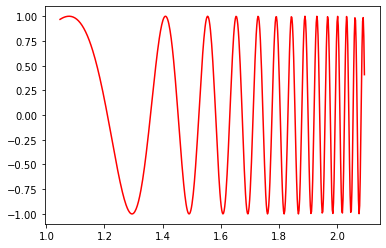

In [11]:
#Define the limits of integration and discretize the independent variable and the function.
# Plot the function to get a feel for what to expect.

xmin=np.pi/3
xmax=2*np.pi/3
#Nx=64
Nx=512
x=np.linspace(xmin,xmax,Nx+1)
f=np.zeros(Nx+1)
for n in range(Nx+1):
    f[n]=fx(x[n])
    
plt.plot(x, f, 'r')
plt.show()

In [13]:
# Calculate the integral 

Ms=9
for m in range(Ms):
    Nx=4**(m+2)
    Dx=(xmax-xmin)/Nx
    x=np.linspace(xmin,xmax,Nx+1)
    f=np.zeros(Nx+1)
    for n in range(Nx+1):
        f[n]=fx(x[n])
        
    Intrect=rectnv(f, xmin, xmax)
    Inttrap=trapznv(f, xmin, xmax)
    Intsimp=simpnv(f, xmin, xmax)
    
    print('%8i'%Nx,'%12.7f'%Iexact,'%12.7f'%Intrect,'%12.7f'%Inttrap,'%12.7f'%Intsimp) 
    

      16    0.0665582    0.1467912    0.1284800    0.1090597
      64    0.0665582    0.0641971    0.0596193    0.0189240
     256    0.0665582    0.0673873    0.0662428    0.0665805
    1024    0.0665582    0.0668249    0.0665388    0.0665583
    4096    0.0665582    0.0666285    0.0665570    0.0665582
   16384    0.0665582    0.0665760    0.0665582    0.0665582
   65536    0.0665582    0.0665627    0.0665582    0.0665582
  262144    0.0665582    0.0665594    0.0665582    0.0665582
 1048576    0.0665582    0.0665585    0.0665582    0.0665582


___________________________________________________________________________________________________________________________

### Team activity #2 (link to your team's breakout room)
#### Time it! ... and compare it to `spi.trapz` and `spi.simps` routines
Insert appropriate lines of code to the previous exercise in order to 

a) time the integral calculations;

b) compare the results with those obtained from the `sci.trapz` and `sci.simps` functions. These functions are called as spi.trapz(f,x) and spi.simps(f,x).

Print all results. 

In [ ]:
# your code here


### Return to main room

In [14]:
# Solution:

# Time the integral 

Ms=9
for m in range(Ms):
    Nx=4**(m+2)
    Dx=(xmax-xmin)/Nx
    x=np.linspace(xmin,xmax,Nx+1)
    f=np.zeros(Nx+1)
    
    start = time.time()
    
    for n in range(Nx+1):
        f[n]=fx(x[n])
        
    Irect=rectnv(f, xmin, xmax)
    Itrap=trapznv(f, xmin, xmax)
    Isimp=simpnv(f, xmin, xmax)
    
    end = time.time()
    Tims = end - start
    
    print('%8i'%Nx,'%12.7f'%Iexact,'%12.7f'%Irect,'%12.7f'%Itrap,'%12.7f'%Isimp, '%20.4e' %Tims) 

      16    0.0665582    0.1467912    0.1284800    0.1090597           0.0000e+00
      64    0.0665582    0.0641971    0.0596193    0.0189240           1.0109e-03
     256    0.0665582    0.0673873    0.0662428    0.0665805           1.0073e-03
    1024    0.0665582    0.0668249    0.0665388    0.0665583           2.9900e-03
    4096    0.0665582    0.0666285    0.0665570    0.0665582           1.0937e-02
   16384    0.0665582    0.0665760    0.0665582    0.0665582           3.8895e-02
   65536    0.0665582    0.0665627    0.0665582    0.0665582           1.3464e-01
  262144    0.0665582    0.0665594    0.0665582    0.0665582           5.3561e-01
 1048576    0.0665582    0.0665585    0.0665582    0.0665582           2.1941e+00


In [15]:
Ms=9
for m in range(Ms):
    Nx=4**(m+2)
    Dx=(xmax-xmin)/Nx
    x=np.linspace(xmin,xmax,Nx+1)
    f=np.zeros(Nx+1)
    
    for n in range(Nx+1):
        f[n]=fx(x[n])
        
    Irect=rectnv(f, xmin, xmax)
    Itrap=trapznv(f, xmin, xmax)
    Isimp=simpnv(f, xmin, xmax)    
    
    Ispitrapz = spi.trapz(f,x)
    Ispisimps = spi.simps(f,x)
    
    print('%8i'%Nx,'%12.7f'%Iexact,'%12.7f'%Irect,'%12.7f'%Itrap,'%12.7f'%Isimp, '%12.7f'%Ispitrapz, '%12.7f'%Ispisimps)  

      16    0.0665582    0.1467912    0.1284800    0.1090597    0.1284800    0.1090597
      64    0.0665582    0.0641971    0.0596193    0.0189240    0.0596193    0.0189240
     256    0.0665582    0.0673873    0.0662428    0.0665805    0.0662428    0.0665805
    1024    0.0665582    0.0668249    0.0665388    0.0665583    0.0665388    0.0665583
    4096    0.0665582    0.0666285    0.0665570    0.0665582    0.0665570    0.0665582
   16384    0.0665582    0.0665760    0.0665582    0.0665582    0.0665582    0.0665582
   65536    0.0665582    0.0665627    0.0665582    0.0665582    0.0665582    0.0665582
  262144    0.0665582    0.0665594    0.0665582    0.0665582    0.0665582    0.0665582
 1048576    0.0665582    0.0665585    0.0665582    0.0665582    0.0665582    0.0665582
